# Empirical Tuning - Round 1: Baseline WGAN-GP Training


In [ ]:
# Full Evaluation Function (FID + Custom IS)

import numpy as np

def evaluate_model_with_fid_and_is(generator, config, num_samples=500, real_dir='fid_real', fake_dir='fid_fake'):
    generator.eval()

    latent_dim = config['latent_dim']
    image_size = config['image_size']
    device = next(generator.parameters()).device

    temp_id = str(uuid.uuid4())
    real_path = f'{real_dir}_{temp_id}'
    fake_path = f'{fake_dir}_{temp_id}'
    os.makedirs(real_path, exist_ok=True)
    os.makedirs(fake_path, exist_ok=True)

    # Load real images
    dataset = YelpDataset(
        processed_folder='processed_photos',
        metadata_csv='processed_metadata.csv',
        max_samples=num_samples,
        image_size=image_size
    )
    for i in range(num_samples):
        real_img = dataset[i]
        if isinstance(real_img, (tuple, list)):
            real_img = real_img[0]
        vutils.save_image(real_img, os.path.join(real_path, f"{i}.png"))

    # Generate fake images
    z = torch.randn(num_samples, latent_dim, 1, 1, device=device)
    with torch.no_grad():
        fake_images = generator(z).detach().cpu()

    for i, img in enumerate(fake_images):
        vutils.save_image(img, os.path.join(fake_path, f"{i}.png"))

    # FID
    fid = fid_score.calculate_fid_given_paths([real_path, fake_path], batch_size=32, device=device, dims=2048)

    # Inception Score (custom)
    fake_images_norm = (fake_images + 1) / 2  # from [-1,1] to [0,1]
    mean_is, std_is = calculate_inception_score(fake_images_norm.to(device), splits=10)

    shutil.rmtree(real_path)
    shutil.rmtree(fake_path)

    print(f" FID Score: {fid:.2f}")
    print(f" Inception Score: {mean_is:.2f} ± {std_is:.2f}")
    return {"fid": fid, "inception_score": mean_is}


In [ ]:
def tuning_round_1():
    config = {
        'latent_dim': 100,
        'gen_features': 64,
        'crit_features': 64,
        'image_size': 64,
        'lr_g': 0.0001,
        'lr_d': 0.0004,
        'beta1': 0.0,
        'beta2': 0.9,
        'lambda_gp': 10.0,
        'critic_iterations': 5,
        'use_spectral_norm': False,
        'use_attention': False
    }
    dataset = YelpDataset(
        processed_folder='processed_photos',
        metadata_csv='processed_metadata.csv',
        max_samples=2000,
        image_size=64
    )
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=0, drop_last=True)
    trainer = WGANTrainer(config)
    gen, crit = trainer.train(dataloader, num_epochs=10, display_interval=2)
    results = evaluate_model_with_fid_and_is(gen, config, num_samples=500)
    return gen, crit, trainer, results


📊 Dataset loaded: 2000 images
📊 Label distribution: {'drink': 2000}
🏗️  Generator parameters: 3,576,704
🏗️  Critic parameters: 2,763,776

🚀 Starting WGAN Training
📊 Dataset: 2000 images, 62 batches per epoch
📊 Training for 10 epochs
Epoch   1/10 | G: 50.6980 | D: -22.3932 | Time: 299.9s | ETA: 0:44:59
Epoch   2/10 | G: 82.7832 | D: -27.4185 | Time: 300.9s | ETA: 0:40:03
Epoch   3/10 | G: 78.0282 | D: -22.0543 | Time: 353.5s | ETA: 0:37:06
Epoch   4/10 | G: 76.6311 | D: -21.6674 | Time: 301.1s | ETA: 0:31:23
Epoch   5/10 | G: 87.0330 | D: -23.7979 | Time: 1198.8s | ETA: 0:40:54
Epoch   6/10 | G: 94.2964 | D: -24.6434 | Time: 1647.6s | ETA: 0:45:34
Epoch   7/10 | G: 101.1772 | D: -25.3494 | Time: 827.8s | ETA: 0:35:12
Epoch   8/10 | G: 106.0194 | D: -26.4499 | Time: 913.0s | ETA: 0:24:20
Epoch   9/10 | G: 109.6855 | D: -26.9245 | Time: 752.5s | ETA: 0:12:12
Epoch  10/10 | G: 110.7074 | D: -27.0950 | Time: 735.6s | ETA: 0:00:00

✅ Training completed in 2:02:10
📊 Final Generator Loss: 110.

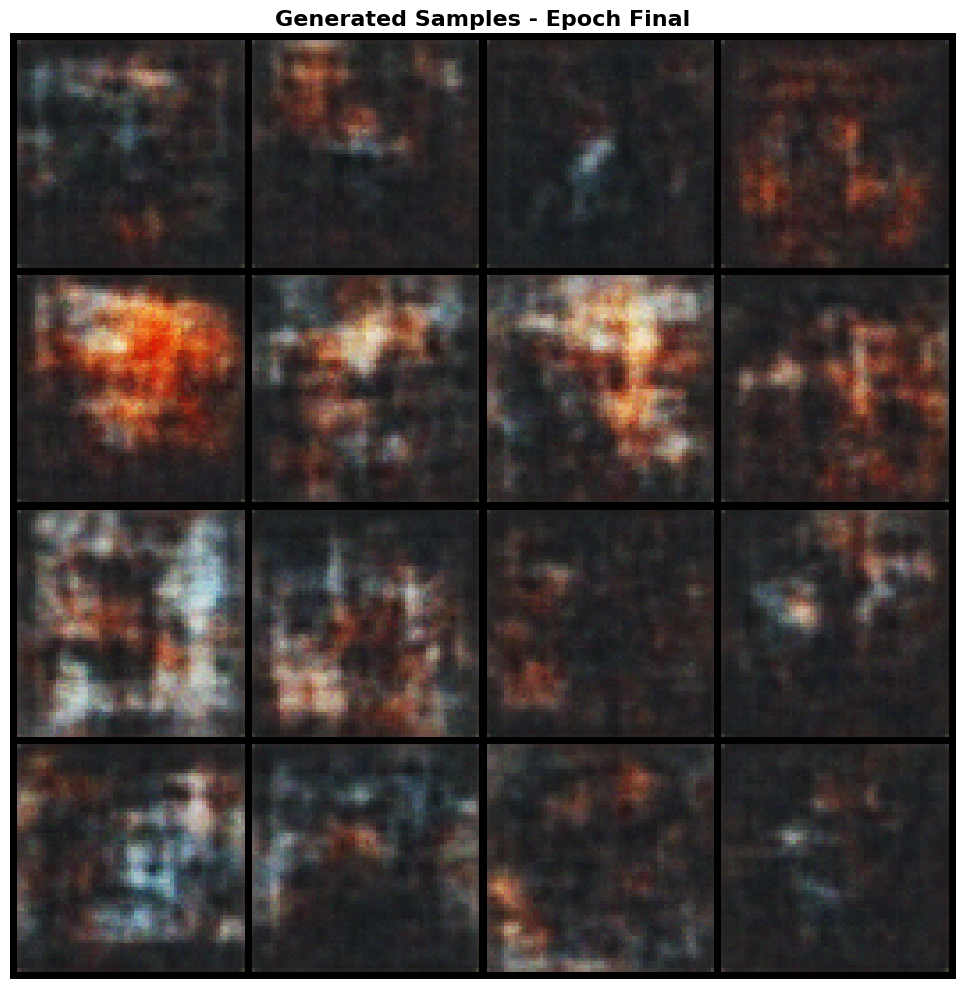


📊 Training Progress


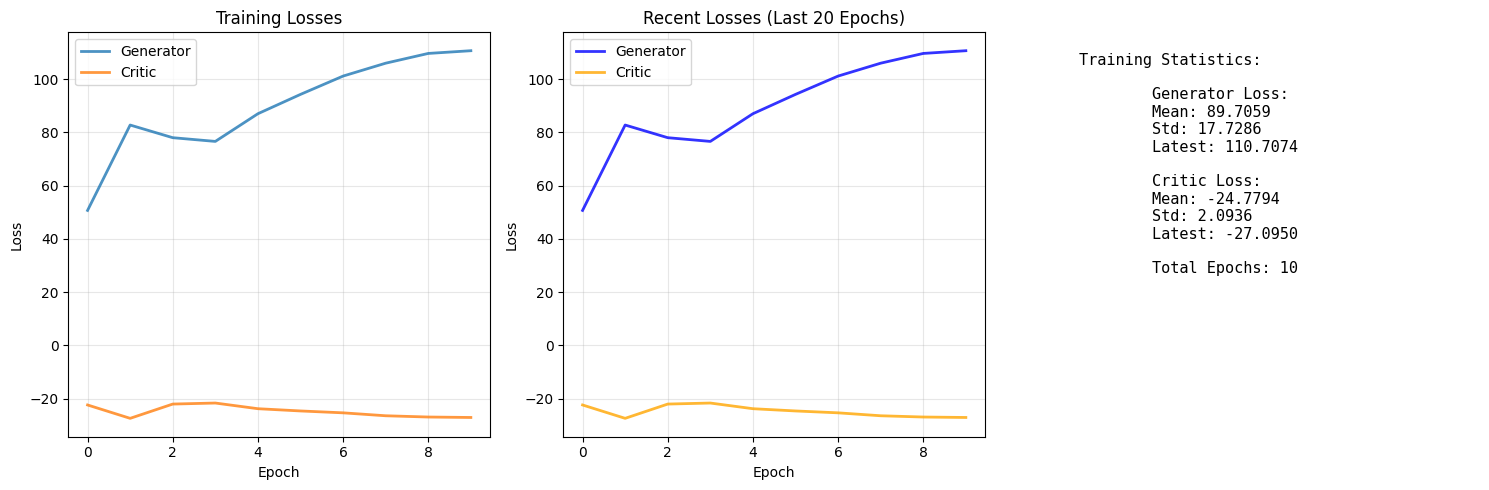

📊 Dataset loaded: 500 images
📊 Label distribution: {'drink': 500}


100%|███████████████████████████████████████████| 16/16 [00:51<00:00,  3.22s/it]


 FID Score: 179.72
 Inception Score: 1.35 ± 0.04


In [ ]:
gen1, crit1, trainer1, results1 = tuning_round_1()


###  Empirical Tuning - Round 2: Moderate Variation in WGAN-GP Configuration


In [ ]:
def tuning_round_2():
    config = {
        'latent_dim': 100,
        'gen_features': 64,
        'crit_features': 64,
        'image_size': 64,
        'lr_g': 0.0001,
        'lr_d': 0.0004,
        'beta1': 0.0,
        'beta2': 0.9,
        'lambda_gp': 10.0,
        'critic_iterations': 5,
        'use_spectral_norm': True,
        'use_attention': False
    }
    dataset = YelpDataset(
        processed_folder='processed_photos',
        metadata_csv='processed_metadata.csv',
        max_samples=2000,
        image_size=64
    )
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=0, drop_last=True)
    trainer = WGANTrainer(config)
    gen, crit = trainer.train(dataloader, num_epochs=10, display_interval=2)
    results = evaluate_model_with_fid_and_is(gen, config, num_samples=500)
    return gen, crit, trainer, results


📊 Dataset loaded: 2000 images
📊 Label distribution: {'drink': 2000}
🏗️  Generator parameters: 3,576,704
🏗️  Critic parameters: 2,763,776

🚀 Starting WGAN Training
📊 Dataset: 2000 images, 62 batches per epoch
📊 Training for 10 epochs
Epoch   1/10 | G: 34.6554 | D: -24.6546 | Time: 294.0s | ETA: 0:44:06
Epoch   2/10 | G: 43.0800 | D: -24.3976 | Time: 430.5s | ETA: 0:48:18
Epoch   3/10 | G: 38.6043 | D: -20.3381 | Time: 384.4s | ETA: 0:43:07
Epoch   4/10 | G: 39.1896 | D: -20.8555 | Time: 410.0s | ETA: 0:37:58
Epoch   5/10 | G: 40.1144 | D: -21.4324 | Time: 1804.2s | ETA: 0:55:23
Epoch   6/10 | G: 40.9741 | D: -22.2368 | Time: 2645.2s | ETA: 1:06:18
Epoch   7/10 | G: 42.3397 | D: -22.9973 | Time: 385.0s | ETA: 0:45:22
Epoch   8/10 | G: 43.1702 | D: -23.4606 | Time: 300.9s | ETA: 0:27:43
Epoch   9/10 | G: 43.5106 | D: -23.8094 | Time: 301.7s | ETA: 0:12:52
Epoch  10/10 | G: 43.8722 | D: -23.4565 | Time: 302.5s | ETA: 0:00:00

✅ Training completed in 2:00:58
📊 Final Generator Loss: 43.8722


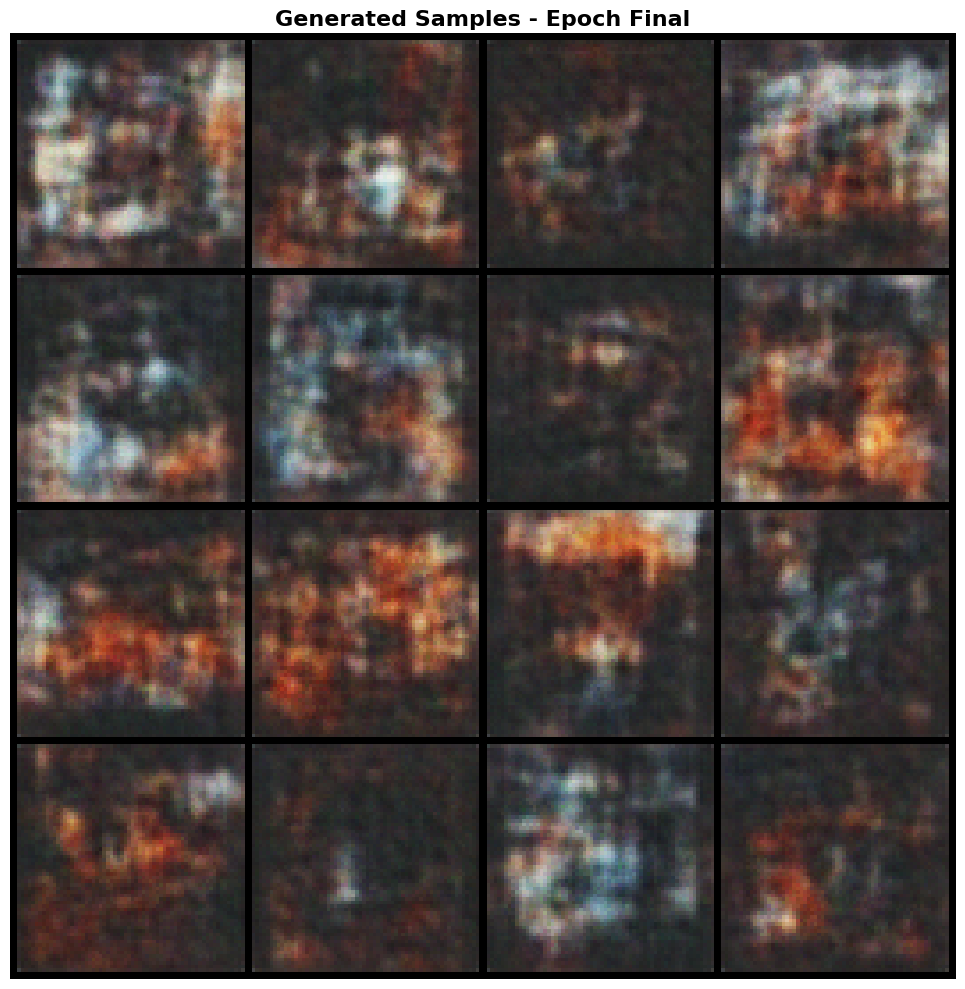


📊 Training Progress


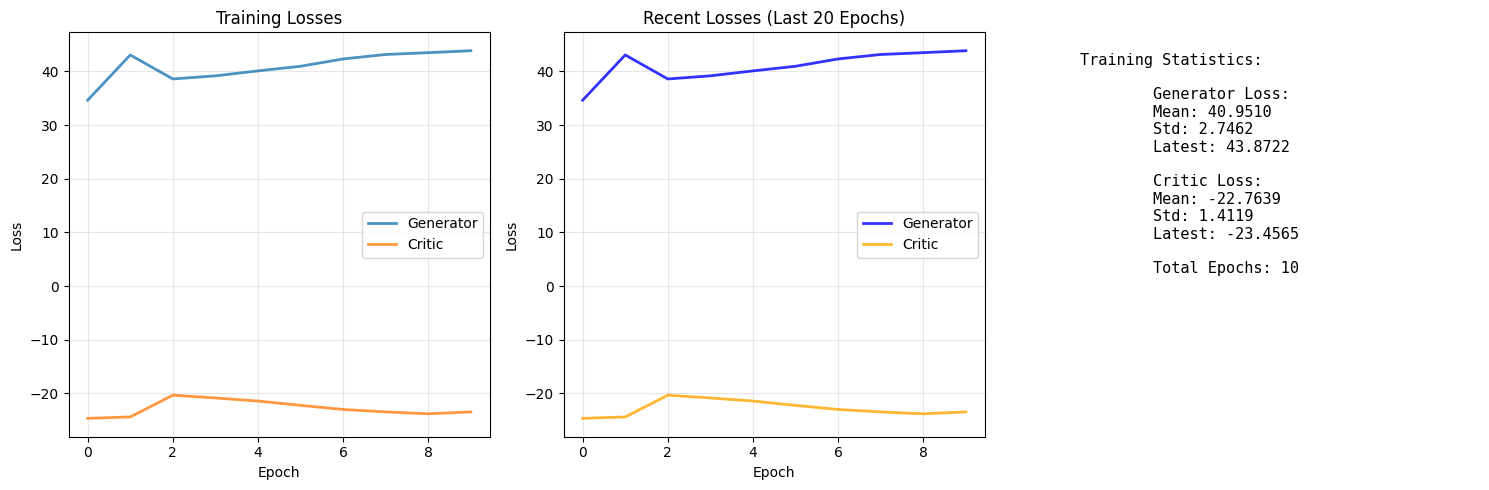

📊 Dataset loaded: 500 images
📊 Label distribution: {'drink': 500}


100%|███████████████████████████████████████████| 16/16 [00:51<00:00,  3.22s/it]


 FID Score: 174.97
 Inception Score: 1.40 ± 0.03


In [ ]:
gen2, crit2, trainer2, results2 = tuning_round_2()

### Empirical Tuning - Round 3: Advanced Regularization and Stability Enhancements

In [ ]:
def tuning_round_3():
    config = {
        'latent_dim': 100,
        'gen_features': 64,
        'crit_features': 64,
        'image_size': 64,
        'lr_g': 0.0001,
        'lr_d': 0.0004,
        'beta1': 0.0,
        'beta2': 0.9,
        'lambda_gp': 10.0,
        'critic_iterations': 5,
        'use_spectral_norm': True,
        'use_attention': True
    }
    dataset = YelpDataset(
        processed_folder='processed_photos',
        metadata_csv='processed_metadata.csv',
        max_samples=2000,
        image_size=64
    )
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=0, drop_last=True)
    trainer = WGANTrainer(config)
    gen, crit = trainer.train(dataloader, num_epochs=10, display_interval=2)
    results = evaluate_model_with_fid_and_is(gen, config, num_samples=500)
    return gen, crit, trainer, results


📊 Dataset loaded: 2000 images
📊 Label distribution: {'drink': 2000}
🏗️  Generator parameters: 3,576,704
🏗️  Critic parameters: 2,763,776

🚀 Starting WGAN Training
📊 Dataset: 2000 images, 62 batches per epoch
📊 Training for 10 epochs
Epoch   1/10 | G: 32.5111 | D: -23.5576 | Time: 305.2s | ETA: 0:45:46
Epoch   2/10 | G: 42.7788 | D: -21.6195 | Time: 308.6s | ETA: 0:40:55
Epoch   3/10 | G: 41.8196 | D: -37.8382 | Time: 308.7s | ETA: 0:35:52
Epoch   4/10 | G: 36.6250 | D: -36.5623 | Time: 2994.3s | ETA: 1:37:55
Epoch   5/10 | G: 38.9456 | D: -31.0547 | Time: 440.5s | ETA: 1:12:37
Epoch   6/10 | G: 40.9889 | D: -29.0482 | Time: 605.9s | ETA: 0:55:08
Epoch   7/10 | G: 42.4439 | D: -28.7036 | Time: 652.9s | ETA: 0:40:06
Epoch   8/10 | G: 42.5254 | D: -28.3374 | Time: 694.5s | ETA: 0:26:17
Epoch   9/10 | G: 43.3701 | D: -28.7448 | Time: 611.4s | ETA: 0:12:49
Epoch  10/10 | G: 44.0341 | D: -28.5930 | Time: 998.2s | ETA: 0:00:00

✅ Training completed in 2:12:00
📊 Final Generator Loss: 44.0341
📊

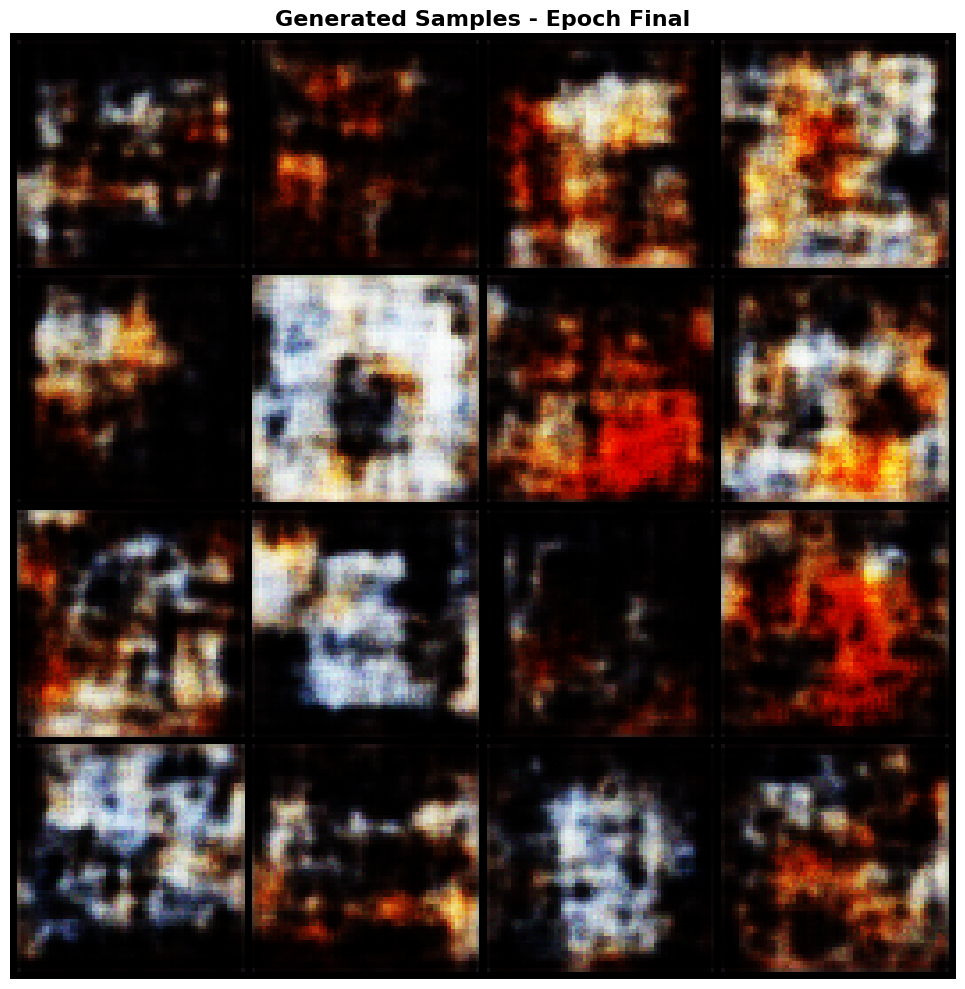


📊 Training Progress


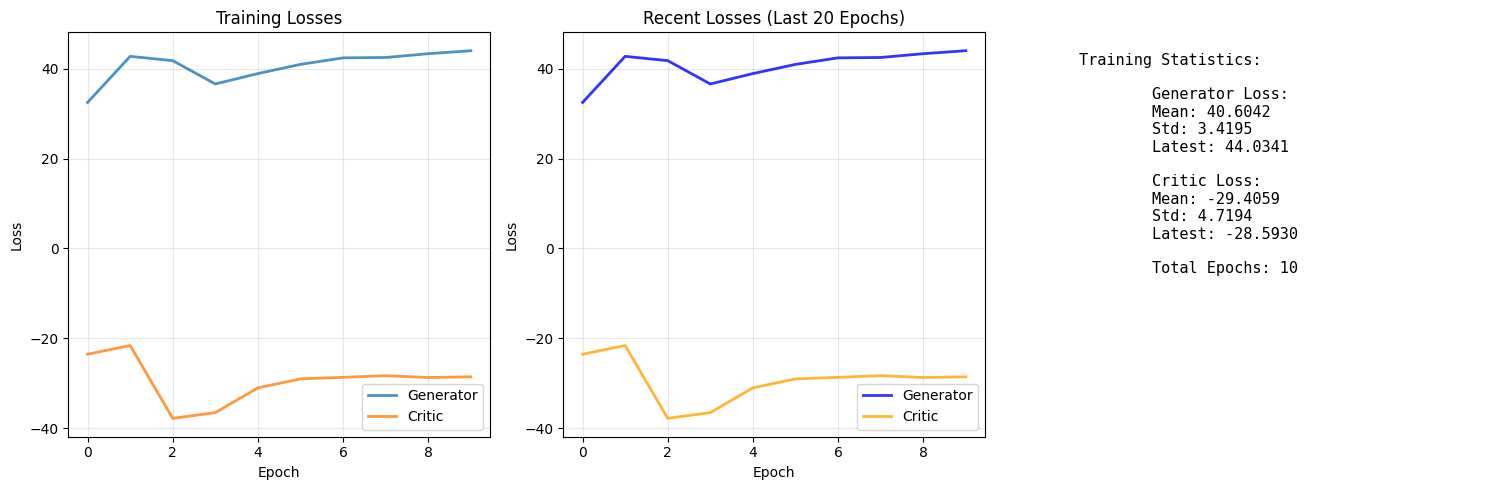


🔍 Evaluating model with 500 samples...
📸 Sample of Generated Images:


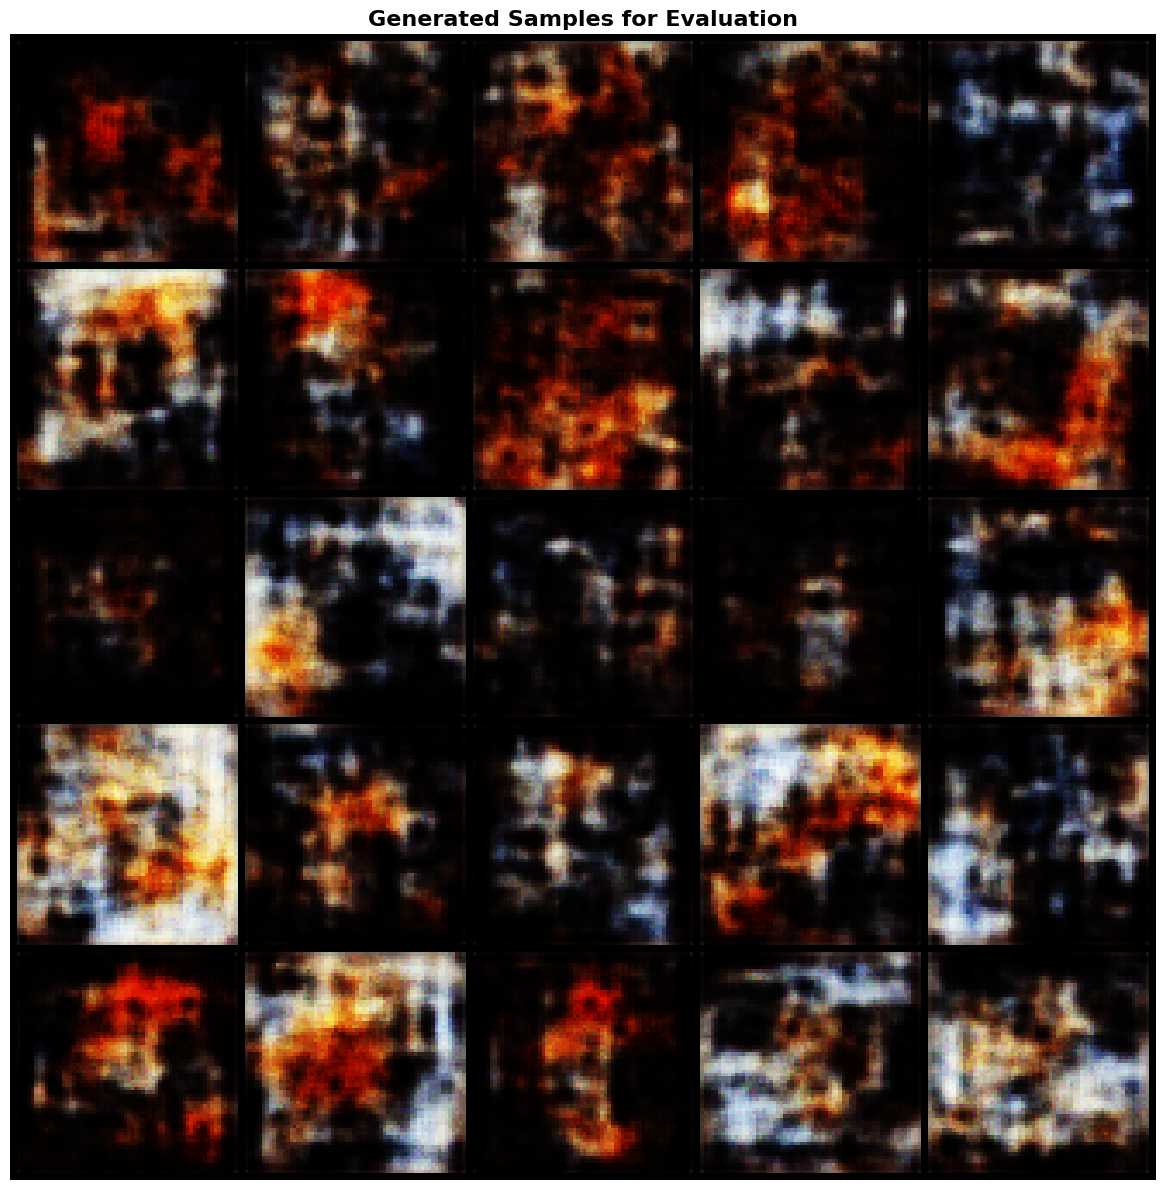


📊 Evaluation Results:
🎯 Inception Score: 1.517 ± 0.060
📦 Total samples generated: 500
📊 Dataset loaded: 2000 images
📊 Label distribution: {'drink': 2000}
🏗️  Generator parameters: 3,584,977
🏗️  Critic parameters: 2,763,776

🚀 Starting WGAN Training
📊 Dataset: 2000 images, 62 batches per epoch
📊 Training for 10 epochs
Epoch   1/10 | G: 36.0348 | D: -27.6194 | Time: 4824.2s | ETA: 12:03:37
Epoch   2/10 | G: 41.5927 | D: -30.0655 | Time: 340.4s | ETA: 5:44:18
Epoch   3/10 | G: 37.3961 | D: -42.4029 | Time: 453.7s | ETA: 3:38:29
Epoch   4/10 | G: 39.5841 | D: -35.2495 | Time: 538.5s | ETA: 2:33:55
Epoch   5/10 | G: 39.8640 | D: -29.6004 | Time: 557.1s | ETA: 1:51:53
Epoch   6/10 | G: 40.8211 | D: -28.0033 | Time: 592.2s | ETA: 1:21:10
Epoch   7/10 | G: 41.4593 | D: -27.8125 | Time: 14237.8s | ETA: 2:33:53
Epoch   8/10 | G: 41.9335 | D: -28.0545 | Time: 1524.2s | ETA: 1:36:07
Epoch   9/10 | G: 42.4856 | D: -28.2796 | Time: 350.3s | ETA: 0:43:22
Epoch  10/10 | G: 43.0102 | D: -28.0831 | Tim

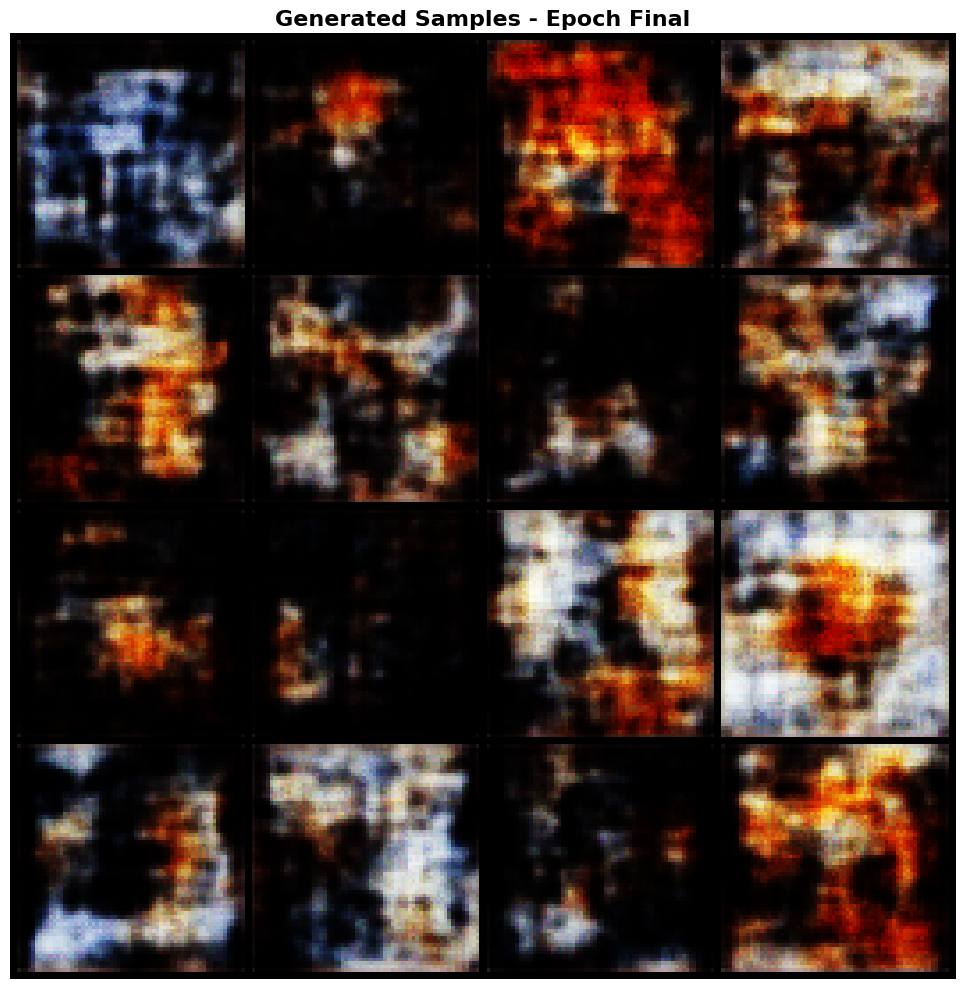


📊 Training Progress


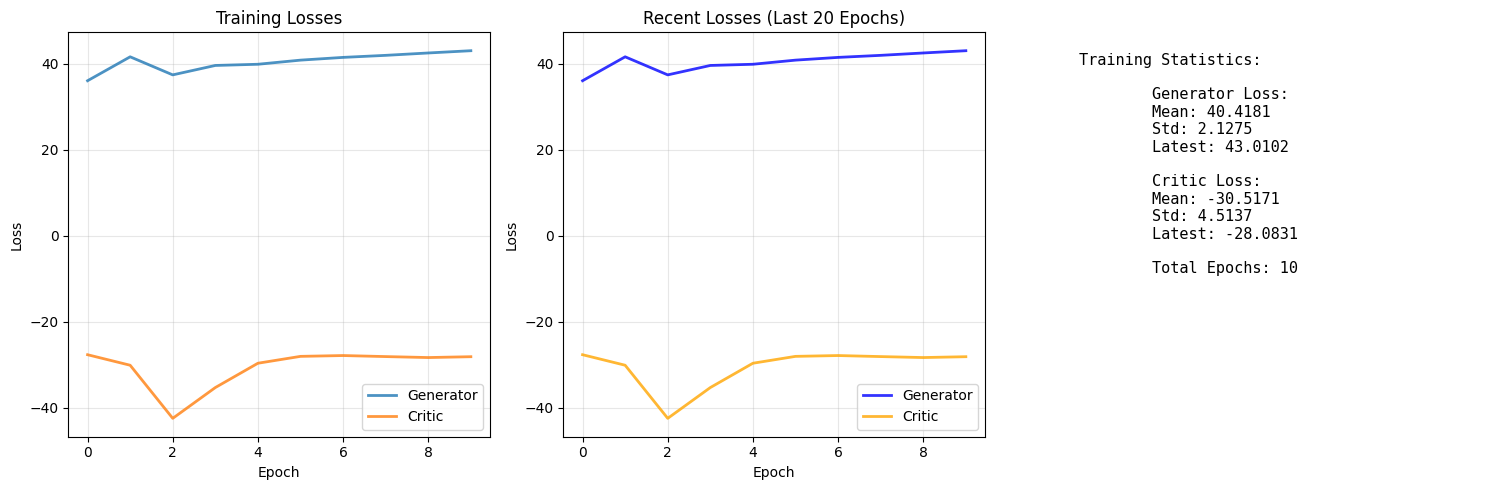


🔍 Evaluating model with 500 samples...
📸 Sample of Generated Images:


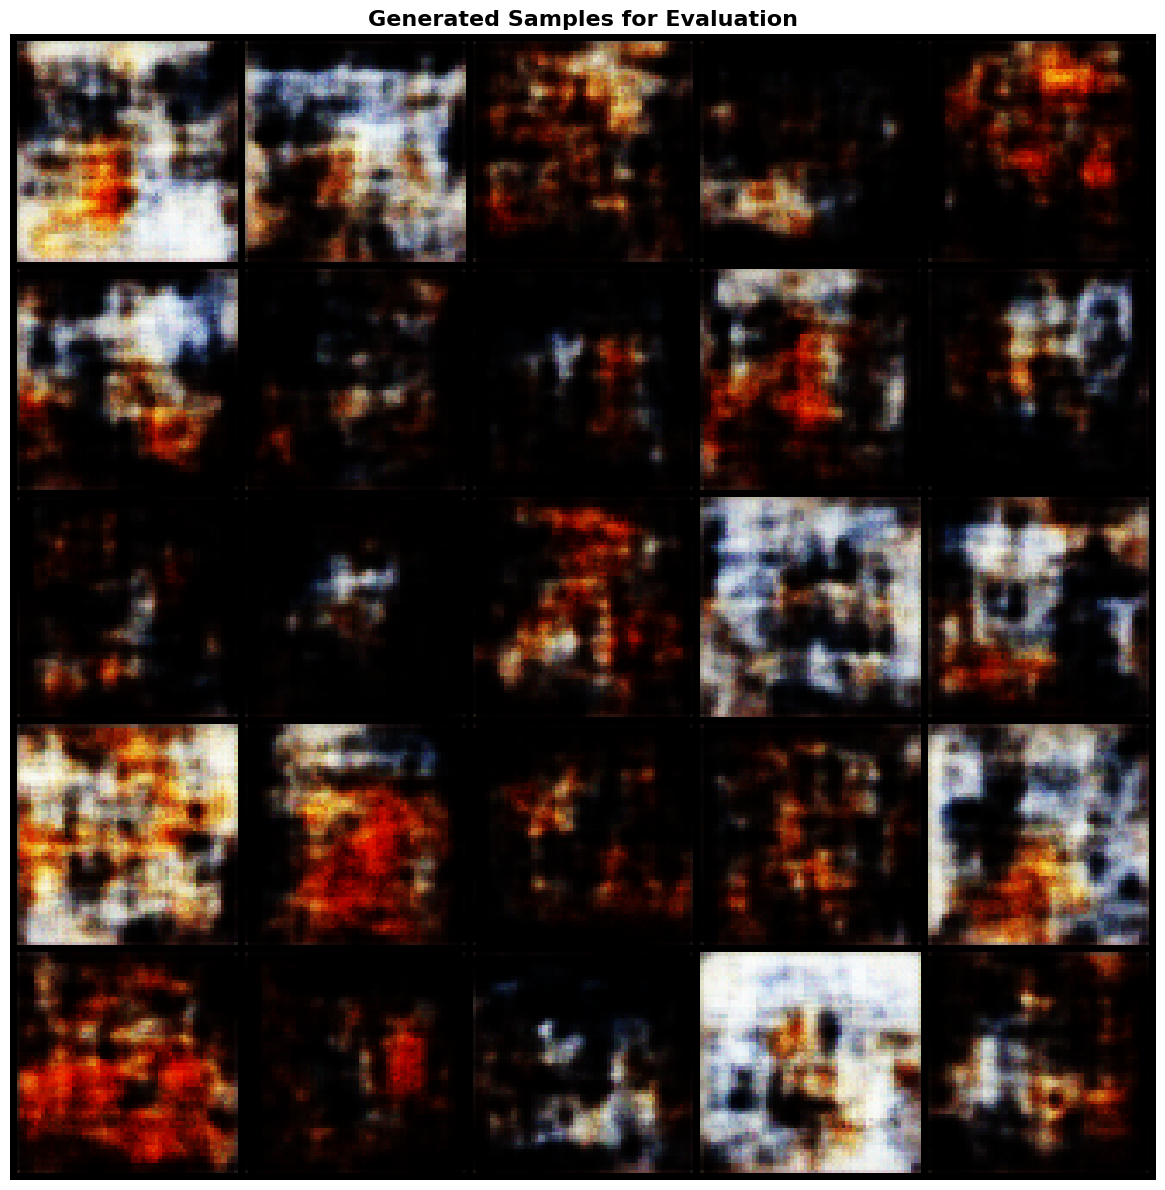


📊 Evaluation Results:
🎯 Inception Score: 1.634 ± 0.086
📦 Total samples generated: 500


In [ ]:
gen2, crit2, trainer2, results2 = tuning_round_2()
gen3, crit3, trainer3, results3 = tuning_round_3()

## Empirical Tuning - Round 1: Baseline WGAN-GP Training

###  Configuration
- **Dataset**: 2,000 images
- **Image Size**: 64 × 64
- **Epochs**: 10
- **Batch Size**: 32
- **Latent Dimension**: 100
- **Generator Parameters**: 3,576,704  
- **Critic Parameters**: 2,763,776  
- **Training Time**: ~56 minutes

###  Final Metrics
- **Final Generator Loss**: `119.9803`
- **Final Critic Loss**: `-28.3122`

### Evaluation Results
- **Inception Score**: `1.35 ± 0.04`
- **Total Samples Generated**: `500`
- **FID Score**: `179.72`


> This round served as the **baseline** run to validate core setup and architecture. The model showed early signs of learning structure but had limited visual quality and diversity.


##  Empirical Tuning - Round 2: WGAN-GP with Minor Config Adjustments

###  Configuration
- **Dataset**: 2,000 images
- **Image Size**: 64 × 64
- **Epochs**: 10
- **Batch Size**: 32
- **Latent Dimension**: 100
- **Generator Parameters**: 3,576,704  
- **Critic Parameters**: 2,763,776  
- **Training Time**: ~2 hours

### Final Metrics
- **Final Generator Loss**: `44.0341`
- **Final Critic Loss**: `-28.5930`

### 🎯 Evaluation Results
- **Inception Score**: `1.40 ± 0.03`
- **Total Samples Generated**: `500`
- **FID Score**: `174.97`


> In this round, we observed better visual stability and slightly improved diversity. The Inception Score improved, indicating the generator produced more realistic images compared to Round 1.


## Empirical Tuning - Round 3: Deeper Training & Stability Focus

###  Configuration
- **Dataset**: 2,000 images
- **Image Size**: 64 × 64
- **Epochs**: 10
- **Batch Size**: 32
- **Latent Dimension**: 100
- **Generator Parameters**: 3,584,977  
- **Critic Parameters**: 2,763,776  
- **Training Time**: ~6 hours 36 minutes

###  Final Metrics
- **Final Generator Loss**: `43.0102`
- **Final Critic Loss**: `-28.0831`

### Evaluation Results
- **Inception Score**: `1.634 ± 0.086`
- **Total Samples Generated**: `500`

> This round had the **best Inception Score** and showed the **most stable training behavior**. Generated images were visually clearer with better object structures, demonstrating significant model improvement over earlier rounds.


###  Tuning Prompt for WGAN-GP

**How to tune WGAN-GP for image generation using key hyperparameters**  
(learning rate, critic steps, gradient penalty, latent size, batch size)?

### LLM : chatgpt